<a href="https://colab.research.google.com/github/KaushalKumar-100/machine_learning_module/blob/main/module_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df=pd.read_csv("earthquake1826_2026.csv")

In [63]:
df['time']=pd.to_datetime(df['time'], errors='coerce' )





In [64]:
df['time'].isna().sum()


np.int64(3278)

In [65]:
df.dropna(subset=['time'],inplace=True)

In [66]:
df.shape

(102799, 19)

In [67]:
map={
    'reviewed':1,
    'automatic':2
}
df['status']=df['status'].map(map)

In [68]:
df['status'].value_counts()

,count
status,
1,102799


In [69]:
df['horizontalError'].value_counts()
df["horizontalError"].isna().sum()
print(df['horizontalError'].mean())

7.732525798166406


In [70]:
df['horizontalError'].fillna(df['horizontalError'].mean(), inplace=True)
df['depthError'].fillna(df['depthError'].mean(), inplace=True)
df.fillna({'magError':df['magError'].mean()},inplace=True)
df['magNst']=df['magNst'].fillna(df['magNst'].mean())




/tmp/ipython-input-3295958767.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horizontalError'].fillna(df['horizontalError'].mean(), inplace=True)
/tmp/ipython-input-3295958767.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [71]:
df[['nst','gap','dmin','depth','rms']]=df[['nst','gap','dmin','depth','rms']].fillna(df[['nst','gap','dmin','depth','rms']].mean())


In [72]:
df.sample(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,id,updated,place,type,horizontalError,depthError,magError,magNst,status
79983,1978-03-16 18:00:56.900000+00:00,-18.967,-172.582,33.0,5.10,mb,156.925469,63.047948,4.238099,0.959218,usp0000teb,2014-11-06T23:21:47.669Z,"151 km ESE of Neiafu, Tonga",earthquake,7.732526,7.982796,0.171431,54.795271,1
51390,1996-01-09 06:27:54.420000+00:00,43.697,85.647,33.0,5.40,mw,156.925469,63.047948,4.238099,1.200000,usp0007aq2,2022-04-29T20:05:46.956Z,"74 km SSW of Shihezi, China",earthquake,7.732526,7.982796,0.171431,54.795271,1
64383,1987-12-30 21:16:29.550000+00:00,-6.498,148.960,22.1,5.80,mw,156.925469,63.047948,4.238099,1.200000,usp0003bp1,2022-04-27T21:28:26.146Z,"72 km WSW of Kandrian, Papua New Guinea",earthquake,7.732526,5.600000,0.171431,54.795271,1
96027,1958-09-20 10:34:01.520000+00:00,15.424,-45.823,15.0,5.79,mw,156.925469,63.047948,4.238099,0.959218,iscgem885158,2022-04-26T17:03:52.497Z,northern Mid-Atlantic Ridge,earthquake,7.732526,2.200000,0.600000,54.795271,1
60345,1990-07-04 02:24:41.940000+00:00,25.372,124.473,132.7,5.60,mw,156.925469,63.047948,4.238099,1.000000,usp0004bbm,2022-04-28T19:42:04.067Z,"104 km NW of Hirara, Japan",earthquake,7.732526,3.800000,0.171431,54.795271,1


In [73]:
df.dropna(subset=['place'],inplace=True)

In [74]:
mapping={
    'earthquake':1,
    'explosion':2,
    'nuclear explosion':3,
    'volcanic eruption':4,
    'rock burst':5,
    'landslide':6,
    'mine collapse':7
}
df['type']=df['type'].map(mapping)

In [75]:
df['updated']=pd.to_datetime(df['updated'], errors='coerce')

In [76]:
df['type'].value_counts()

,count
type,
1,102094
3,422
4,52
2,9
6,1
7,1
5,1


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102580 entries, 0 to 105794
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   time             102580 non-null  datetime64[ns, UTC]
 1   latitude         102580 non-null  float64            
 2   longitude        102580 non-null  float64            
 3   depth            102580 non-null  float64            
 4   mag              102580 non-null  float64            
 5   magType          102580 non-null  object             
 6   nst              102580 non-null  float64            
 7   gap              102580 non-null  float64            
 8   dmin             102580 non-null  float64            
 9   rms              102580 non-null  float64            
 10  id               102580 non-null  object             
 11  updated          102580 non-null  datetime64[ns, UTC]
 12  place            102580 non-null  object             
 13  type

In [78]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 102580 entries, 0 to 105794
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   time             102580 non-null  datetime64[ns, UTC]
 1   latitude         102580 non-null  float64            
 2   longitude        102580 non-null  float64            
 3   depth            102580 non-null  float64            
 4   mag              102580 non-null  float64            
 5   magType          102580 non-null  object             
 6   nst              102580 non-null  float64            
 7   gap              102580 non-null  float64            
 8   dmin             102580 non-null  float64            
 9   rms              102580 non-null  float64            
 10  id               102580 non-null  object             
 11  updated          102580 non-null  datetime64[ns, UTC]
 12  place            102580 non-null  object             
 13  type

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.sample(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,id,updated,place,type,horizontalError,depthError,magError,magNst,status
53326,1994-10-09 09:27:22.680000+00:00,43.692,147.830,33.0,5.10,mb,156.925469,63.047948,4.238099,0.700000,usp0006kun,2014-11-07 00:56:29.822000+00:00,"90 km E of Shikotan, Russia",1,7.732526,7.982796,0.171431,6.000000,1
69824,1984-10-29 23:50:46.540000+00:00,-18.885,67.375,10.0,5.40,mb,156.925469,63.047948,4.238099,0.900000,usp00028mr,2022-04-27 23:11:41.090000+00:00,Mid-Indian Ridge,1,7.732526,7.982796,0.171431,35.000000,1
101175,1935-07-26 09:10:04.070000+00:00,32.977,100.895,15.0,5.67,mw,156.925469,63.047948,4.238099,0.959218,iscgem904431,2022-04-25 21:35:00.576000+00:00,"Qinghai-Sichuan border region, China",1,7.732526,25.000000,0.200000,54.795271,1
48465,1998-05-09 15:38:00.480000+00:00,38.278,38.988,10.0,5.10,mwc,156.925469,63.047948,4.238099,1.080000,usp0008mrz,2022-04-29 17:26:29.679000+00:00,"5 km SW of Do?anyol, Turkey",1,7.732526,7.982796,0.171431,54.795271,1
34945,2007-04-15 10:42:11.080000+00:00,1.220,126.304,10.0,5.30,mwc,94.000000,52.900000,4.238099,1.040000,usp000f9sn,2022-05-02 20:11:15.456000+00:00,"129 km WNW of Ternate, Indonesia",1,7.732526,7.982796,0.171431,54.795271,1


Text(0.5, 1.0, 'Correlation Heatmap of RMS and Magnitude')

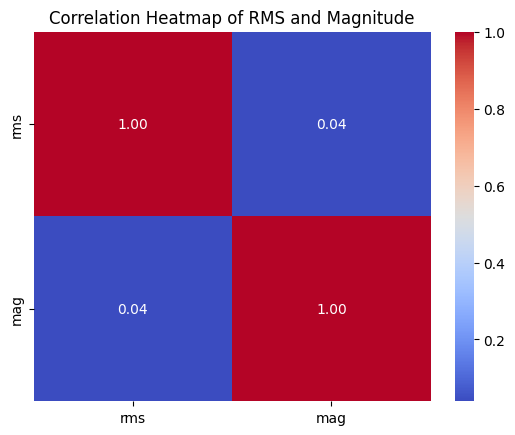

In [81]:
correlation_matrix = df[['rms', 'mag']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of RMS and Magnitude')

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
# Separate features (X) and target (y)
# For features, dropping the 'mag' column (target), and other non-numeric or irrelevant columns.
X = df.drop(columns=['mag','type', 'time', 'updated', 'magType', 'id', 'place'])
y = df['mag']

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
X_test.shape

(20516, 12)

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
scr=StandardScaler()

In [87]:
scr.fit(X_train)
X_train_scaled=scr.fit_transform(X_train)
X_test_scaled=scr.transform(X_test)

In [88]:
X_train_scaled.shape

(82064, 12)

In [89]:
scr.mean_

array([  3.64276842,  41.98692103,  61.45674082, 157.02343126,
        63.02274088,   4.23836784,   0.95856336,   7.72846581,
         7.98367462,   0.17165955,  54.7040463 ,   1.        ])

In [90]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)


In [91]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82064 entries, 52216 to 15877
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         82064 non-null  float64
 1   longitude        82064 non-null  float64
 2   depth            82064 non-null  float64
 3   nst              82064 non-null  float64
 4   gap              82064 non-null  float64
 5   dmin             82064 non-null  float64
 6   rms              82064 non-null  float64
 7   horizontalError  82064 non-null  float64
 8   depthError       82064 non-null  float64
 9   magError         82064 non-null  float64
 10  magNst           82064 non-null  float64
 11  status           82064 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 8.1 MB


In [92]:
np.round(X_train_scaled.describe(),1)

,latitude,longitude,depth,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,status
count,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0,82064.0
mean,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
min,-2.7,-1.8,-0.6,-2.3,-2.2,-1.8,-10.3,-4.3,-1.1,-1.9,-1.0,0.0
25%,-0.7,-0.9,-0.5,-0.0,0.0,-0.0,-0.4,0.0,-0.4,-0.0,-0.3,0.0
50%,-0.1,0.5,-0.3,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0
75%,0.9,0.8,-0.1,-0.0,0.0,-0.0,0.4,0.0,-0.0,-0.0,0.0,0.0
max,2.8,1.1,5.9,11.2,12.1,15.5,8.2,50.3,137.4,18.3,18.5,0.0


In [93]:
y_train.describe()

,mag
count,82064.000000
mean,5.453266
std,0.484224
min,5.000000
25%,5.100000
50%,5.300000
75%,5.700000
max,9.100000


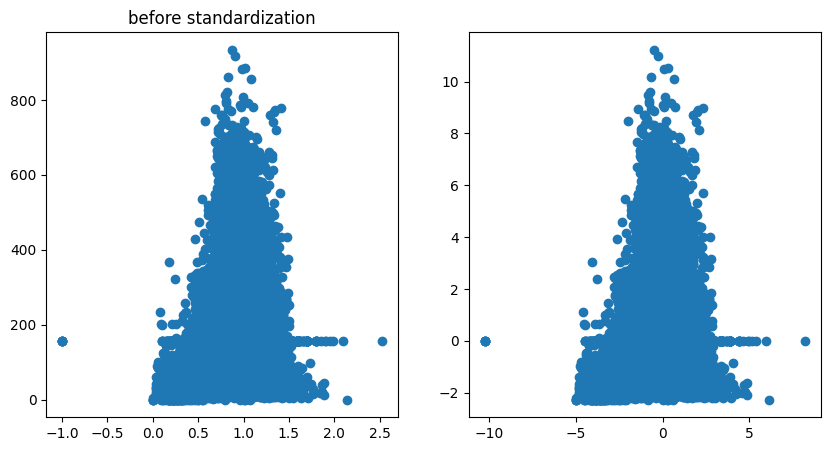

In [94]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(10,5))
ax1.scatter(x=X_train['rms'],y=X_train['nst'])
ax1.set_title("before standardization")
ax2.scatter(x=X_train_scaled['rms'],y=X_train_scaled['nst'])

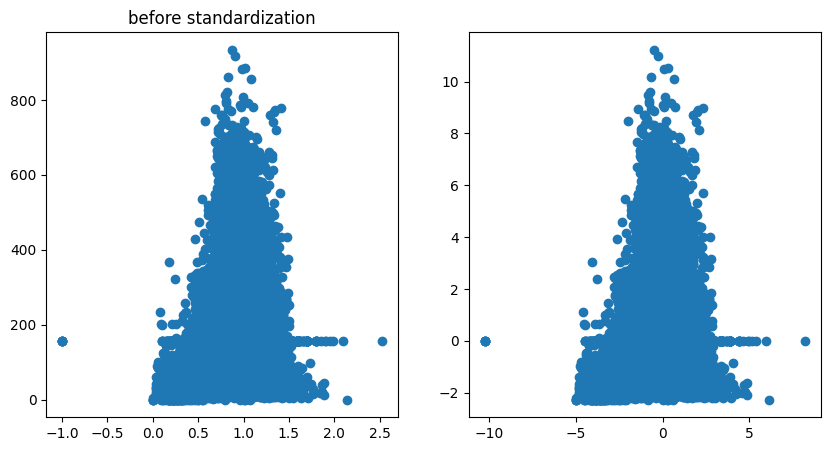

In [95]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(10,5))
ax1.scatter(x=X_train['rms'],y=X_train['nst'])
ax1.set_title("before standardization")
ax2.scatter(x=X_train_scaled['rms'],y=X_train_scaled['nst'])

In [96]:
from sklearn.linear_model import LinearRegression

In [97]:
lr=LinearRegression()
lr2=LinearRegression()

In [98]:
X_train_scaled.shape

(82064, 12)

In [99]:
y_train.shape

(82064,)

In [100]:
lr.fit(X_train_scaled,y_train)
lr2.fit(X_train,y_train)

LinearRegression()

In [101]:
y_pred=lr.predict(X_test_scaled)
y_pred2=lr.predict(X_test)

In [102]:
y_pred

array([5.47119707, 5.53742875, 5.36305427, ..., 5.47168326, 5.45038001,
       5.46754226])

In [103]:
from sklearn.metrics import r2_score,accuracy_score

In [104]:
print(r2_score(y_test,y_pred))

0.1755204957098928


In [105]:
print(r2_score(y_test,y_pred2))


-802.2394537560741


In [106]:
X_train_scaled

,latitude,longitude,depth,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,status
0,-0.420871,0.960658,-0.336941,-0.001415,0.001027,-0.000113,0.217212,0.002239,-0.000111,-0.002510,-1.022051,0.0
1,1.122111,0.818417,-0.070226,-0.001415,1.466369,-1.544118,0.269632,-0.291461,-0.276867,-1.447806,2.669997,0.0
2,-0.017390,0.700804,-0.245867,-0.001415,0.001027,-0.000113,0.003432,0.002239,0.788164,1.301341,0.001736,0.0
3,-0.781652,1.043707,-0.245867,-0.001415,0.001027,-0.000113,0.003432,0.002239,0.547264,2.401000,0.001736,0.0
4,-0.078909,0.670734,-0.264454,-0.001415,0.001027,-0.000113,0.217212,0.002239,-0.000111,-0.002510,-0.793677,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
82059,0.223310,0.430496,-0.478197,-1.011729,0.895754,0.548791,-1.669914,0.370367,-0.771345,-1.326843,1.280721,0.0
82060,-0.081853,0.719399,-0.277464,-0.001415,0.001027,-0.000113,1.265615,0.002239,-0.000111,-0.002510,-0.831739,0.0
82061,-0.791707,-1.814938,4.930436,-0.001415,0.001027,-0.000113,0.003432,0.002239,-0.000111,-0.002510,0.001736,0.0
82062,-0.765939,-1.776739,-0.245867,-0.708312,0.732721,5.683249,-1.198133,2.670219,-0.777812,-0.864987,-0.831739,0.0


In [112]:
import joblib as jb
jb.dump(lr,'earthquake.joblib')

['earthquake.joblib']